# Resample Data
I want to resample data so they have data points for every period (or NaN points if missing). Lets explore my data periods.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
def plot_timeseries(dfs, value_column, 
                   plot_type='line', 
                   sample_rate=None, 
                   date_range=None,
                   figsize=(15, 8),
                   highlight_filled=False,
                   filled_df=None,
                   title=None,
                   labels=None):
    """
    Plots time series data from a list of DataFrames with a 'timestamp' column.
    Each DataFrame is plotted as a separate line with the same style but different colors.

    Args:
        dfs (list of pd.DataFrame): List of DataFrames with time series data (must have 'timestamp' column)
        value_column (str): Name of the value column
        plot_type (str): 'line', 'scatter', 'both', or 'resampled'
        sample_rate (int): If provided, sample to at most this many points per DataFrame
        date_range (tuple): (start_date, end_date) to filter the data
        figsize (tuple): Figure size (width, height)
        highlight_filled (bool): Whether to highlight ARIMA-filled values (only works with single DF)
        filled_df (pd.DataFrame): DataFrame with filled values (if highlighting)
        title (str): Custom plot title
        labels (list): Custom labels for each DataFrame (if None, uses DF1, DF2, etc.)

    Returns:
        matplotlib.figure.Figure

    Examples:
        # Basic usage with multiple DataFrames
        fig = plot_timeseries([df1, df2, df3], 'Value')

        # With custom labels and plot type
        fig = plot_timeseries([original_df, resampled_df], 'Diff.', 
                             labels=['Original', 'Resampled'],
                             plot_type='line')

        # Comparing different preprocessing results
        fig = plot_timeseries([raw_data, hourly_resampled, interpolated], 'Value',
                             labels=['Raw', 'Hourly', 'Interpolated'],
                             title='Data Preprocessing Comparison')
    """

    # Input validation
    if not isinstance(dfs, list):
        raise ValueError("First parameter must be a list of DataFrames")

    if len(dfs) == 0:
        raise ValueError("List of DataFrames cannot be empty")

    # Check that all DataFrames have 'timestamp' column
    for i, df in enumerate(dfs):
        if 'timestamp' not in df.columns:
            raise ValueError(f"DataFrame {i} must have a 'timestamp' column")
        if value_column not in df.columns:
            raise ValueError(f"Column '{value_column}' not found in DataFrame {i}")

    # Default labels if not provided
    if labels is None:
        labels = [f"DF{i+1}" for i in range(len(dfs))]
    elif len(labels) != len(dfs):
        raise ValueError("Number of labels must match number of DataFrames")

    # Color palette for different lines - use tab10 colormap for up to 10 distinct colors
    if len(dfs) < 5:
        colors_line = plt.cm.tab10([0, 3, 6, 9])
        colors_scatter = plt.cm.tab10([1, 4, 7, 8])
    else:
        # For more than 10 DataFrames, use a continuous colormap
        colors_line = plt.cm.viridis(np.linspace(0, 1, len(dfs)))
        colors_scatter = colors_line  # Use same colors for scatter when many DFs

    # Prepare DataFrames
    dfs_plot = []
    total_points = 0

    for i, df in enumerate(dfs):
        # Work on a copy
        df_plot = df.copy()
        
        # Ensure timestamp column is datetime
        df_plot['timestamp'] = pd.to_datetime(df_plot['timestamp'])

        # Filter by date range
        if date_range:
            start_date, end_date = date_range
            df_plot = df_plot[(df_plot['timestamp'] >= start_date) & 
                             (df_plot['timestamp'] <= end_date)]

        # Downsample if requested
        if sample_rate and len(df_plot) > sample_rate:
            step = max(1, len(df_plot)//sample_rate)
            df_plot = df_plot.iloc[::step]

        dfs_plot.append(df_plot)
        total_points += len(df_plot)
        print(f"DataFrame {i+1} ({labels[i]}): {len(df_plot)} points")

    if date_range:
        print(f"Filtered to date range: {total_points} total points")

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    if title is None:
        title = f"Time Series Plot - {value_column} ({total_points:,} total points)"

    # Plot each DataFrame
    for i, (df_plot, label) in enumerate(zip(dfs_plot, labels)):
        if len(df_plot) == 0:
            continue

        # Get appropriate colors
        color_line = colors_line[i]
        color_scatter = colors_scatter[i] if i < len(colors_scatter) else color_line

        # Plot types - all DataFrames use same style but different colors
        if plot_type == 'line':
            ax.plot(df_plot['timestamp'], df_plot[value_column],
                    linewidth=1, alpha=1, color=color_line, label=label)

        elif plot_type == 'scatter':
            ax.scatter(df_plot['timestamp'], df_plot[value_column],
                       s=1, alpha=0.6, color=color_scatter, label=label)

        elif plot_type == 'both':
            ax.plot(df_plot['timestamp'], df_plot[value_column],
                    linewidth=0.8, alpha=0.8, color=color_line, label=f'{label} (Line)')
            ax.scatter(df_plot['timestamp'], df_plot[value_column],
                       s=1, alpha=0.6, color=color_scatter, label=f'{label} (Points)')

        elif plot_type == 'resampled':
            # For resampling, temporarily set timestamp as index
            df_temp = df_plot.set_index('timestamp')
            df_resampled = df_temp[value_column].resample('h').mean()
            ax.plot(df_resampled.index, df_resampled,
                    linewidth=1, color=color_line, label=f'{label} (Hourly Avg)')
            print(f"DataFrame {i+1} resampled to hourly averages: {len(df_resampled)} points")

    # Highlight filled values (only works with single DataFrame for backwards compatibility)
    if highlight_filled and filled_df is not None and len(dfs) == 1:
        if 'timestamp' not in filled_df.columns:
            raise ValueError("filled_df must also have a 'timestamp' column")
        
        filled_copy = filled_df.copy()
        filled_copy['timestamp'] = pd.to_datetime(filled_copy['timestamp'])
        filled_copy = filled_copy.sort_values('timestamp')

        # Find timestamps in filled_df but missing in original df
        original_timestamps = set(dfs[0]['timestamp'])
        filled_timestamps = set(filled_copy['timestamp'])
        new_times = filled_timestamps - original_timestamps

        if new_times:
            filled_only = filled_copy[filled_copy['timestamp'].isin(new_times)]
            
            if date_range:
                start_date, end_date = date_range
                filled_only = filled_only[(filled_only['timestamp'] >= start_date) & 
                                         (filled_only['timestamp'] <= end_date)]

            if not filled_only.empty:
                ax.scatter(filled_only['timestamp'], filled_only[value_column],
                           s=3, color='red', alpha=0.8,
                           label='ARIMA Filled', zorder=5)
                print(f"Highlighted {len(filled_only)} filled values")

    # Labels and formatting
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel(value_column, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Enhanced stats box for multiple DataFrames
    stats_lines = []
    for i, (df_plot, label) in enumerate(zip(dfs_plot, labels)):
        if len(df_plot) > 0:
            stats_lines.append(f"{label}:")
            stats_lines.append(f"  Min: {df_plot[value_column].min():.2f}")
            stats_lines.append(f"  Max: {df_plot[value_column].max():.2f}")
            stats_lines.append(f"  Mean: {df_plot[value_column].mean():.2f}")
            stats_lines.append(f"  Std: {df_plot[value_column].std():.2f}")
            if i < len(dfs_plot) - 1:  # Add separator except for last
                stats_lines.append("---")

    stats_text = "\n".join(stats_lines)

    # Adjust stats box font size based on number of DataFrames
    font_size = max(8, min(10, 10 - len(dfs) // 3))

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.8), fontsize=font_size)

    plt.tight_layout()
    plt.show()
    #return fig


# Convenience function for common use cases
def compare_preprocessing_results(original_df, resampled_df, interpolated_df=None, 
                                 value_column='Value', **kwargs):
    """
    Convenience function to compare original, resampled, and optionally interpolated data.

    Args:
        original_df: Original water meter data
        resampled_df: Resampled hourly data  
        interpolated_df: Optional interpolated data
        value_column: Column to plot
        **kwargs: Additional arguments passed to plot_timeseries
    """
    dfs = [original_df, resampled_df]
    labels = ['Original', 'Resampled']

    if interpolated_df is not None:
        dfs.append(interpolated_df)
        labels.append('Interpolated')

    return plot_timeseries(dfs, value_column, labels=labels, 
                          title=f'Data Preprocessing Comparison - {value_column}',
                          **kwargs)


## Test on random df

In [5]:
test_df = pd.read_csv('./test/data/VAR_41494_55419-odecty.csv', sep=";")[['Time of reading', 'Value', 'Diff.']]
test_df.rename(columns={'Time of reading':'timestamp'}, inplace=True)
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17267 entries, 0 to 17266
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  17267 non-null  object 
 1   Value      17267 non-null  float64
 2   Diff.      17266 non-null  float64
dtypes: float64(2), object(1)
memory usage: 404.8+ KB


DataFrame 1 (DF1): 17267 points


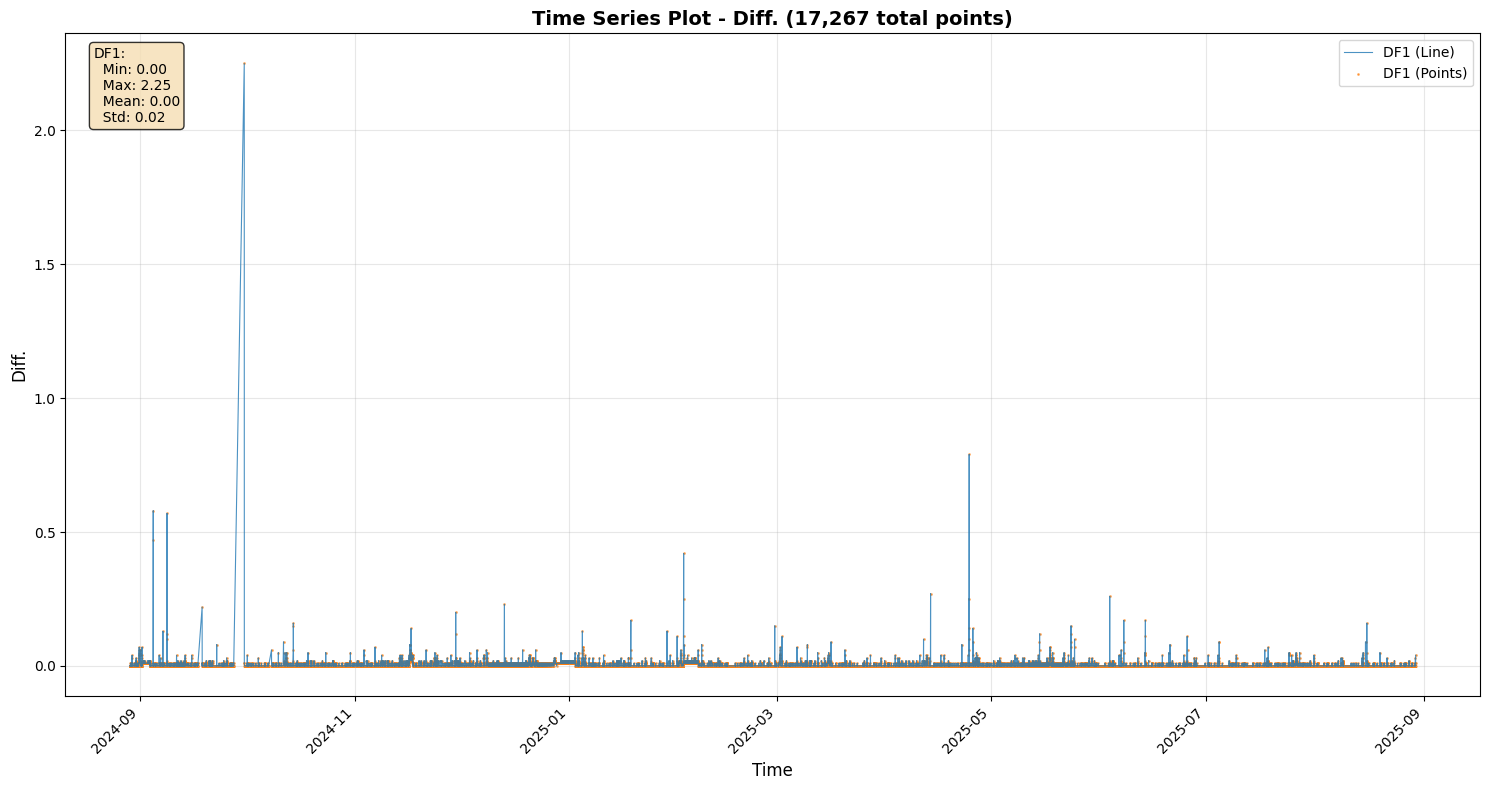

In [6]:
plot_timeseries([test_df], 'Diff.', 'both')

In [7]:
test_df.head(10)

,timestamp,Value,Diff.
0,2025-08-29 17:06:45.0,851.44,0.04
1,2025-08-29 16:36:45.0,851.40,0.00
2,2025-08-29 16:06:45.0,851.40,0.01
3,2025-08-29 15:36:45.0,851.39,0.01
4,2025-08-29 15:06:45.0,851.38,0.03
5,2025-08-29 14:36:45.0,851.35,0.00
6,2025-08-29 14:06:45.0,851.35,0.00
7,2025-08-29 13:36:45.0,851.35,0.00
8,2025-08-29 13:06:45.0,851.35,0.00
9,2025-08-29 12:36:45.0,851.35,0.00


In [8]:
def fill_gaps_with_periodicity(df, periodicity_minutes=30, tolerance_minutes=5):
    """
    Fill gaps in time-series data for a single VAR_ID sensor.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: 'timestamp', 'Value', 'Diff.' (and optionally 'VAR_ID')
        Must contain data for a single sensor only.
    periodicity_minutes : int
        Expected time interval between consecutive readings in minutes (e.g., 30)
    tolerance_minutes : int
        Tolerance window for matching timestamps to expected grid (e.g., 5 minutes)
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with filled gaps (NaN for missing values)
    dict
        Dictionary with diagnostic information including detailed unmatched readings
    """
    
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # Ensure timestamp is datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Sort by timestamp
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    # Get time range
    start_time = df['timestamp'].min()
    end_time = df['timestamp'].max()
    
    # Create expected timestamp range at the specified periodicity
    freq_str = f'{periodicity_minutes}min'  # 'min' for minutes in pandas
    expected_timestamps = pd.date_range(start=start_time, end=end_time, freq=freq_str)
    
    # Create a DataFrame with expected timestamps
    filled_df = pd.DataFrame({'timestamp': expected_timestamps})
    
    # For each actual timestamp, find the nearest expected timestamp within tolerance
    df['matched_timestamp'] = df['timestamp'].apply(
        lambda x: _find_nearest_timestamp(x, expected_timestamps, tolerance_minutes)
    )
    
    # Identify rows that couldn't be matched (outside tolerance)
    unmatched = df[df['matched_timestamp'].isna()].copy()
    matched = df[df['matched_timestamp'].notna()].copy()
    
    # Handle duplicates: if multiple readings match the same expected timestamp, keep the closest one
    if len(matched) > 0:
        matched['time_diff'] = abs((matched['timestamp'] - matched['matched_timestamp']).dt.total_seconds())
        matched = matched.sort_values('time_diff').drop_duplicates(subset=['matched_timestamp'], keep='first')
        matched = matched.drop(columns=['time_diff'])
    
    # Merge with expected timestamps
    if len(matched) > 0:
        filled_df = filled_df.merge(
            matched[['matched_timestamp', 'Value', 'Diff.']],
            left_on='timestamp',
            right_on='matched_timestamp',
            how='left'
        )
        filled_df = filled_df.drop(columns=['matched_timestamp'])
    else:
        filled_df['Value'] = np.nan
        filled_df['Diff.'] = np.nan
    
    # Preserve VAR_ID if it exists
    if 'VAR_ID' in df.columns:
        var_id = df['VAR_ID'].iloc[0]
        filled_df.insert(0, 'VAR_ID', var_id)
    
    # Calculate diagnostics
    total_expected = len(expected_timestamps)
    total_actual = len(df)
    total_filled = len(filled_df)
    missing_count = filled_df['Value'].isna().sum()
    duplicate_count = len(df) - len(matched) - len(unmatched)
    
    # Calculate expected samples per day
    expected_per_day = (24 * 60) / periodicity_minutes
    
    # Calculate actual samples per day
    filled_df['date'] = filled_df['timestamp'].dt.date
    samples_per_day = filled_df.groupby('date').size()
    
    # Build detailed unmatched readings list
    unmatched_detail = []
    for idx, row in unmatched.iterrows():
        # Find the closest expected slot
        time_diffs = abs((expected_timestamps - row['timestamp']).total_seconds() / 60)
        nearest_idx = time_diffs.argmin()
        expected_slot = expected_timestamps[nearest_idx]
        
        # Get previous and next readings in the original data
        prev_idx = idx - 1 if idx > 0 else None
        next_idx = idx + 1 if idx < len(df) - 1 else None
        
        prev_row = df.loc[prev_idx] if prev_idx is not None else None
        next_row = df.loc[next_idx] if next_idx is not None else None
        
        unmatched_detail.append({
            'reading_timestamp': row['timestamp'],
            'value': row['Value'],
            'diff': row['Diff.'],
            'expected_slot': expected_slot,
            'time_difference_minutes': time_diffs[nearest_idx],
            'prev_reading_timestamp': prev_row['timestamp'] if prev_row is not None else None,
            'prev_reading_value': prev_row['Value'] if prev_row is not None else None,
            'next_reading_timestamp': next_row['timestamp'] if next_row is not None else None,
            'next_reading_value': next_row['Value'] if next_row is not None else None
        })
    
    diagnostics = {
        'total_expected_timestamps': total_expected,
        'total_actual_readings': total_actual,
        'total_after_filling': total_filled,
        'missing_values_filled': missing_count,
        'unmatched_readings_count': len(unmatched),
        'unmatched_readings_detail': unmatched_detail,
        'duplicate_readings_removed': duplicate_count,
        'expected_samples_per_day': expected_per_day,
        'actual_samples_per_day': samples_per_day.to_dict(),
        'date_range': f"{start_time.date()} to {end_time.date()}",
        'periodicity_used_minutes': periodicity_minutes,
        'tolerance_used_minutes': tolerance_minutes
    }
    
    # Drop temporary date column
    filled_df = filled_df.drop(columns=['date'])
    
    return filled_df, diagnostics


def _find_nearest_timestamp(actual_ts, expected_ts_series, tolerance_minutes):
    """
    Find the nearest expected timestamp within tolerance.
    
    Parameters:
    -----------
    actual_ts : pandas.Timestamp
        The actual timestamp from the data
    expected_ts_series : pandas.DatetimeIndex
        Series of expected timestamps
    tolerance_minutes : int
        Maximum allowed difference in minutes
        
    Returns:
    --------
    pandas.Timestamp or None
        Nearest expected timestamp if within tolerance, otherwise None
    """
    # Calculate time differences
    time_diffs = abs((expected_ts_series - actual_ts).total_seconds() / 60)
    
    # Find minimum difference
    min_diff_idx = time_diffs.argmin()
    min_diff = time_diffs[min_diff_idx]
    
    # Return nearest timestamp if within tolerance
    if min_diff <= tolerance_minutes:
        return expected_ts_series[min_diff_idx]
    else:
        return None



In [9]:
filled_df, diagnostics = fill_gaps_with_periodicity(test_df)

In [10]:
print("=" * 80)
print("FILLED DATAFRAME")
print("=" * 80)
print(filled_df)
print()

print("=" * 80)
print("DIAGNOSTICS SUMMARY")
print("=" * 80)
for key, value in diagnostics.items():
    if key != 'unmatched_readings_detail':
        print(f"{key}: {value}")
print()

print("=" * 80)
print("UNMATCHED READINGS DETAIL")
print("=" * 80)
if diagnostics['unmatched_readings_detail']:
    for i, unmatched in enumerate(diagnostics['unmatched_readings_detail'], 1):
        print(f"\nUnmatched Reading #{i}:")
        print(f"  Reading timestamp: {unmatched['reading_timestamp']}")
        print(f"  Value: {unmatched['value']}, Diff: {unmatched['diff']}")
        print(f"  Expected slot: {unmatched['expected_slot']}")
        print(f"  Time difference: {unmatched['time_difference_minutes']:.2f} minutes")
        print(f"  Previous reading: {unmatched['prev_reading_timestamp']} (Value: {unmatched['prev_reading_value']})")
        print(f"  Next reading: {unmatched['next_reading_timestamp']} (Value: {unmatched['next_reading_value']})")
else:
    print("No unmatched readings found!")

# Save outputs
filled_df.to_csv('filled_data_complete.csv', index=False)
print(f"\n{'=' * 80}")
print("Output saved to: filled_data_complete.csv")
print("=" * 80)


FILLED DATAFRAME
                timestamp   Value  Diff.
0     2024-08-29 00:14:56  789.73    NaN
1     2024-08-29 00:44:56  789.73    0.0
2     2024-08-29 01:14:56  789.73    0.0
3     2024-08-29 01:44:56  789.73    0.0
4     2024-08-29 02:14:56  789.73    0.0
...                   ...     ...    ...
17549 2025-08-29 14:44:56     NaN    NaN
17550 2025-08-29 15:14:56     NaN    NaN
17551 2025-08-29 15:44:56     NaN    NaN
17552 2025-08-29 16:14:56     NaN    NaN
17553 2025-08-29 16:44:56     NaN    NaN

[17554 rows x 3 columns]

DIAGNOSTICS SUMMARY
total_expected_timestamps: 17554
total_actual_readings: 17267
total_after_filling: 17554
missing_values_filled: 6912
unmatched_readings_count: 6624
duplicate_readings_removed: 1
expected_samples_per_day: 48.0
actual_samples_per_day: {datetime.date(2024, 8, 29): 48, datetime.date(2024, 8, 30): 48, datetime.date(2024, 8, 31): 48, datetime.date(2024, 9, 1): 48, datetime.date(2024, 9, 2): 48, datetime.date(2024, 9, 3): 48, datetime.date(2024, 9

In [11]:
filled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17554 entries, 0 to 17553
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  17554 non-null  datetime64[ns]
 1   Value      10642 non-null  float64       
 2   Diff.      10641 non-null  float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 411.6 KB


DataFrame 1 (DF1): 17554 points


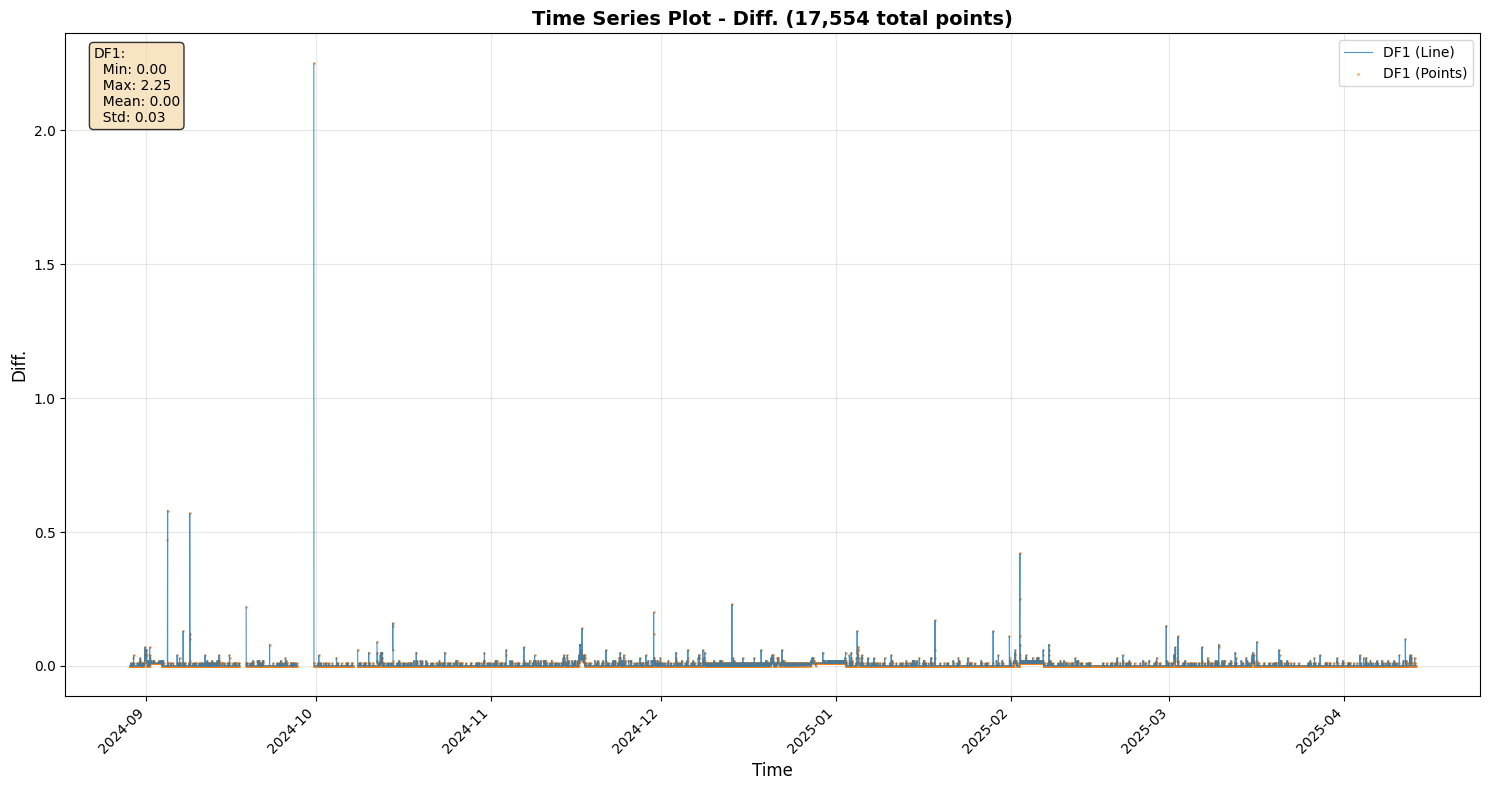

In [12]:
plot_timeseries([filled_df], 'Diff.', 'both')

In [ ]:

def fill_gaps_with_periodicity_adaptive(df, periodicity_minutes=30, tolerance_minutes=5):
    """
    Fill gaps in time-series data for a single VAR_ID sensor using adaptive timestamp generation.
    Instead of creating a full expected range upfront, this function builds the expected timeline
    iteratively based on actual readings, adjusting for timing drift.
    
    -----------
    df : pandas.DataFrame
        DataFrame with columns: 'timestamp', 'Value', 'Diff.' (and optionally 'VAR_ID')
        Must contain data for a single sensor only.
    periodicity_minutes : int
        Expected time interval between consecutive readings in minutes (e.g., 30)
    Parameters:
    tolerance_minutes : int
        Tolerance window for matching timestamps to expected grid (e.g., 5 minutes)
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with filled gaps (NaN for missing values)
    dict
        Dictionary with diagnostic information including detailed unmatched readings
    """
    
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # Ensure timestamp is datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    if len(df) == 0:
        return df, {}
    
    # Initialize variables for adaptive timeline building
    result_rows = []
    unmatched_detail = []
    matched_indices = set()
    
    # Start with the first timestamp
    current_idx = 0
    expected_next = df.loc[0, 'timestamp']
    
    # Track the original data end time
    data_end_time = df['timestamp'].max()
    
    while expected_next <= data_end_time:
        # Find readings within tolerance of expected_next
        time_diffs = abs((df['timestamp'] - expected_next).dt.total_seconds() / 60)
        within_tolerance = time_diffs <= tolerance_minutes
        
        if within_tolerance.any():
            # Get indices of all readings within tolerance
            candidate_indices = df.index[within_tolerance].tolist()
            
            # Remove already matched indices
            candidate_indices = [idx for idx in candidate_indices if idx not in matched_indices]
            
            if candidate_indices:
                # Find the closest one among candidates
                closest_idx = min(candidate_indices, key=lambda idx: time_diffs[idx])
                
                # Add this reading to results
                row_data = {
                    'timestamp': expected_next,
                    'Value': df.loc[closest_idx, 'Value'],
                    'Diff.': df.loc[closest_idx, 'Diff.']
                }
                
                if 'VAR_ID' in df.columns:
                    row_data['VAR_ID'] = df.loc[closest_idx, 'VAR_ID']
                
                result_rows.append(row_data)
                matched_indices.add(closest_idx)
                
                # Calculate next expected timestamp from the ACTUAL reading
                actual_reading_time = df.loc[closest_idx, 'timestamp']
                expected_next = actual_reading_time + pd.Timedelta(minutes=periodicity_minutes)
            else:
                # No unmatched candidates, add NaN row
                row_data = {
                    'timestamp': expected_next,
                    'Value': np.nan,
                    'Diff.': np.nan
                }
                
                if 'VAR_ID' in df.columns:
                    row_data['VAR_ID'] = df.loc[0, 'VAR_ID']
                
                result_rows.append(row_data)
                expected_next = expected_next + pd.Timedelta(minutes=periodicity_minutes)
        else:
            # No reading within tolerance, add NaN row
            row_data = {
                'timestamp': expected_next,
                'Value': np.nan,
                'Diff.': np.nan
            }
            
            if 'VAR_ID' in df.columns:
                row_data['VAR_ID'] = df.loc[0, 'VAR_ID']
            
            result_rows.append(row_data)
            expected_next = expected_next + pd.Timedelta(minutes=periodicity_minutes)
    
    # Create the filled DataFrame
    filled_df = pd.DataFrame(result_rows)
    
    # Reorder columns to match original
    if 'VAR_ID' in df.columns:
        filled_df = filled_df[['VAR_ID', 'timestamp', 'Value', 'Diff.']]
    else:
        filled_df = filled_df[['timestamp', 'Value', 'Diff.']]
    
    # Identify unmatched readings
    unmatched_indices = [idx for idx in df.index if idx not in matched_indices]
    
    # Build detailed unmatched readings list
    for idx in unmatched_indices:
        row = df.loc[idx]
        
        # Find what the expected slot would have been (closest in our result)
        if len(filled_df) > 0:
            time_diffs_to_result = abs((filled_df['timestamp'] - row['timestamp']).dt.total_seconds() / 60)
            nearest_result_idx = time_diffs_to_result.argmin()
            expected_slot = filled_df.loc[nearest_result_idx, 'timestamp']
            time_diff = time_diffs_to_result.iloc[nearest_result_idx]
        else:
            expected_slot = None
            time_diff = None
        
        # Get previous and next readings in the original data
        prev_idx = idx - 1 if idx > 0 else None
        next_idx = idx + 1 if idx < len(df) - 1 else None
        
        prev_row = df.loc[prev_idx] if prev_idx is not None else None
        next_row = df.loc[next_idx] if next_idx is not None else None
        
        unmatched_detail.append({
            'reading_timestamp': row['timestamp'],
            'value': row['Value'],
            'diff': row['Diff.'],
            'expected_slot': expected_slot,
            'time_difference_minutes': time_diff,
            'prev_reading_timestamp': prev_row['timestamp'] if prev_row is not None else None,
            'prev_reading_value': prev_row['Value'] if prev_row is not None else None,
            'next_reading_timestamp': next_row['timestamp'] if next_row is not None else None,
            'next_reading_value': next_row['Value'] if next_row is not None else None
        })
    
    # Calculate diagnostics
    total_filled = len(filled_df)
    missing_count = filled_df['Value'].isna().sum()
    expected_per_day = (24 * 60) / periodicity_minutes
    
    filled_df['date'] = filled_df['timestamp'].dt.date
    samples_per_day = filled_df.groupby('date').size()
    filled_df = filled_df.drop(columns=['date'])
    
    diagnostics = {
        'total_expected_timestamps': total_filled,
        'total_actual_readings': len(df),
        'total_after_filling': total_filled,
        'total_matched_readings': len(matched_indices),
        'missing_values_filled': missing_count,
        'unmatched_readings_count': len(unmatched_indices),
        'unmatched_readings_detail': unmatched_detail,
        'expected_samples_per_day': expected_per_day,
        'actual_samples_per_day': samples_per_day.to_dict(),
        'date_range': f"{df['timestamp'].min().date()} to {df['timestamp'].max().date()}",
        'periodicity_used_minutes': periodicity_minutes,
        'tolerance_used_minutes': tolerance_minutes
    }
    
    return filled_df, diagnostics



In [16]:
filled_df, diagnostics = fill_gaps_with_periodicity_adaptive(test_df)

In [17]:
print("=" * 80)
print("FILLED DATAFRAME")
print("=" * 80)
print(filled_df)
print()

print("=" * 80)
print("DIAGNOSTICS SUMMARY")
print("=" * 80)
for key, value in diagnostics.items():
    if key != 'unmatched_readings_detail':
        print(f"{key}: {value}")
print()

FILLED DATAFRAME
                timestamp   Value  Diff.
0     2024-08-29 00:14:56  789.73    NaN
1     2024-08-29 00:44:56  789.73   0.00
2     2024-08-29 01:14:56  789.73   0.00
3     2024-08-29 01:44:56  789.73   0.00
4     2024-08-29 02:14:56  789.73   0.00
...                   ...     ...    ...
17550 2025-08-29 15:06:45  851.38   0.03
17551 2025-08-29 15:36:45  851.39   0.01
17552 2025-08-29 16:06:45  851.40   0.01
17553 2025-08-29 16:36:45  851.40   0.00
17554 2025-08-29 17:06:45  851.44   0.04

[17555 rows x 3 columns]

DIAGNOSTICS SUMMARY
total_expected_timestamps: 17555
total_actual_readings: 17267
total_after_filling: 17555
total_matched_readings: 17266
missing_values_filled: 289
unmatched_readings_count: 1
expected_samples_per_day: 48.0
actual_samples_per_day: {datetime.date(2024, 8, 29): 48, datetime.date(2024, 8, 30): 48, datetime.date(2024, 8, 31): 48, datetime.date(2024, 9, 1): 48, datetime.date(2024, 9, 2): 48, datetime.date(2024, 9, 3): 48, datetime.date(2024, 9, 4)

In [18]:
print("=" * 80)
print("UNMATCHED READINGS DETAIL")
print("=" * 80)
if diagnostics['unmatched_readings_detail']:
    for i, unmatched in enumerate(diagnostics['unmatched_readings_detail'], 1):
        print(f"\nUnmatched Reading #{i}:")
        print(f"  Reading timestamp: {unmatched['reading_timestamp']}")
        print(f"  Value: {unmatched['value']}, Diff: {unmatched['diff']}")
        print(f"  Expected slot: {unmatched['expected_slot']}")
        print(f"  Time difference: {unmatched['time_difference_minutes']:.2f} minutes")
        print(f"  Previous reading: {unmatched['prev_reading_timestamp']} (Value: {unmatched['prev_reading_value']})")
        print(f"  Next reading: {unmatched['next_reading_timestamp']} (Value: {unmatched['next_reading_value']})")
else:
    print("No unmatched readings found!")

# Save outputs
filled_df.to_csv('filled_data_complete.csv', index=False)
print(f"\n{'=' * 80}")
print("Output saved to: filled_data_complete.csv")
print("=" * 80)


UNMATCHED READINGS DETAIL

Unmatched Reading #1:
  Reading timestamp: 2024-10-27 02:13:34
  Value: 801.91, Diff: 0.0
  Expected slot: 2024-10-27 02:13:35
  Time difference: 0.02 minutes
  Previous reading: 2024-10-27 01:43:35 (Value: 801.91)
  Next reading: 2024-10-27 02:13:35 (Value: 801.91)

Output saved to: filled_data_complete.csv
